# Barebones 1D SPAD simulations

## Environment

```shell
pip install matplotlib numpy
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def simulate_ihpp1d(intensity_func, T, max_rate=None, seed=None):
    """
    Simulates a non-homogeneous Poisson process using the thinning algorithm.

    Args:
        intensity_func (callable): A function λ(t) defining the time-dependent intensity rate.
        T (float): The end time of the simulation (0 to T).
        max_rate (float): An upper bound for λ(t), the maximum intensity.
        seed: Seed for the numpy random generator.

    Returns:
        np.array: A 1D array of event times.
    """
    rng = np.random.default_rng(seed=seed)
    if max_rate is None:
        # Estimate max_rate by sampling the intensity function at a grid of points
        t_grid = np.linspace(0, T, 1000)
        max_rate = np.max(intensity_func(t_grid))
    # Generate homogeneous Poisson events
    n_events = int(2 * T * max_rate)  # Overestimate the number of events
    u = rng.random(n_events)
    inter_arrival_times = -np.log(u) / max_rate
    event_times = np.cumsum(inter_arrival_times)

    # Keep only those within [0, T]
    event_times = event_times[event_times <= T]

    # Thinning step
    acceptance_probs = rng.random(event_times.shape[0])
    accepted = acceptance_probs <= (intensity_func(event_times) / max_rate)

    return event_times[accepted]

def apply_deadtime_1d(timestamps, deadtime):
    """
    Applies a dead-time effect to a sequence of event timestamps by dropping events
    that occur within `deadtime` of the previous accepted event.

    Originally deadtime_drop_1d(timestamps, deadtime).

    Args:
        timestamps (np.array): A 1D array of event timestamps (assumed sorted).
        deadtime (float): The minimum time interval required between accepted events.

    Returns:
        np.array: A 1D array of timestamps after applying the dead-time effect.
    """
    if len(timestamps) == 0:
        return timestamps
    is_sorted = np.all(timestamps[:-1] <= timestamps[1:])
    if not is_sorted:
        timestamps = np.sort(timestamps)
    accepted = [timestamps[0]]
    for t in timestamps[1:]:
        if t - accepted[-1] >= deadtime:
            accepted.append(t)
    return np.array(accepted)

Sensor 1 - Number of timestamps: 3
Sensor 2 - Number of timestamps: 4


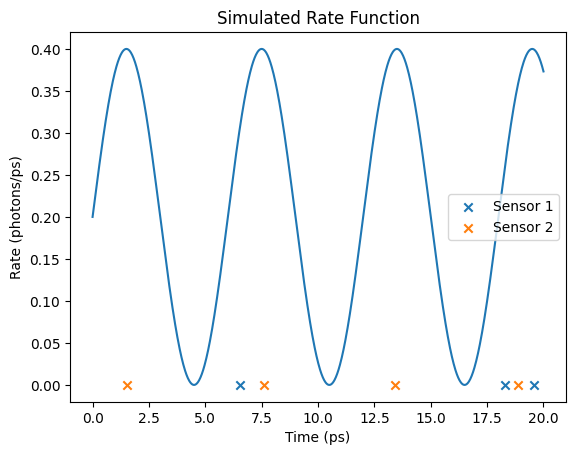

In [5]:
def rate_function(t):
    """
    photons/ps.
    """
    return 0.2 * np.sin(2 * np.pi * t / 6) + 0.2

exposure_time_ps = 20

num_sensors = 2
timestamps_raw = []
for i in range(num_sensors):
    timestamps_raw_single = simulate_ihpp1d(rate_function, exposure_time_ps)
    print(f"Sensor {i+1} - Number of timestamps: {len(timestamps_raw_single)}")
    timestamps_raw.append(timestamps_raw_single)

plt.plot(np.linspace(0, exposure_time_ps, 1000), rate_function(np.linspace(0, exposure_time_ps, 1000)))
for i in range(num_sensors):
    plt.scatter(timestamps_raw[i], np.zeros_like(timestamps_raw[i]), label=f'Sensor {i+1}', marker='x')
plt.xlabel("Time (ps)")
plt.ylabel("Rate (photons/ps)")
plt.title("Simulated Rate Function")
plt.legend()
plt.show()

Sensor 1 - Number of timestamps after non-idealities: 3
Sensor 2 - Number of timestamps after non-idealities: 4


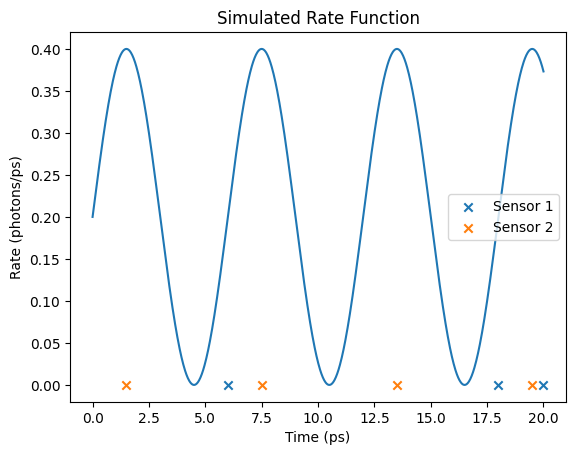

In [6]:
# detector non-idealities
timestamps = [np.copy(ts) for ts in timestamps_raw]
# sensor jitter
jitter_std_ps = 0.5
# sensor deadtime
deadtime_ps = 1.0
# sensor precision
resolution_ps = 0.5

for i in range(num_sensors):
    # jitter
    timestamps[i] += np.random.normal(0, jitter_std_ps, size=timestamps[i].shape)
    # deadtime
    timestamps[i] = np.sort(timestamps[i])
    timestamps[i] = apply_deadtime_1d(timestamps[i], deadtime_ps)
    # precision
    timestamps[i] = np.round(timestamps[i] / resolution_ps) * resolution_ps
    print(f"Sensor {i+1} - Number of timestamps after non-idealities: {len(timestamps[i])}")

plt.plot(np.linspace(0, exposure_time_ps, 1000), rate_function(np.linspace(0, exposure_time_ps, 1000)))
for i in range(num_sensors):
    plt.scatter(timestamps[i], np.zeros_like(timestamps[i]), marker='x', label=f'Sensor {i+1}')
plt.xlabel("Time (ps)")
plt.ylabel("Rate (photons/ps)")
plt.title("Simulated Rate Function")
plt.legend()
plt.show()

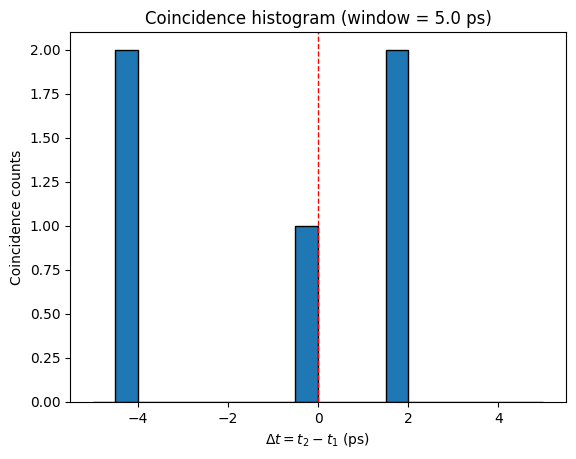

Total coincidences within window: 5


In [7]:
# Coincidence histogram: distribution of time differences dt = t2 - t1
# between detections on the two sensors, within a coincidence window.
coincidence_window_ps = 5.0
bin_width_ps = resolution_ps

t1 = timestamps[0]
t2 = timestamps[1]

# All pairwise differences t2 - t1
dt = (t2[None, :] - t1[:, None]).ravel()
# Keep only pairs falling inside the coincidence window
dt = dt[np.abs(dt) <= coincidence_window_ps]

bins = np.arange(-coincidence_window_ps, coincidence_window_ps + bin_width_ps, bin_width_ps)
counts, edges = np.histogram(dt, bins=bins)

plt.bar(edges[:-1], counts, width=bin_width_ps, align="edge", edgecolor="k")
plt.axvline(0, color="r", ls="--", lw=1)
plt.xlabel(r"$\Delta t = t_2 - t_1$ (ps)")
plt.ylabel("Coincidence counts")
plt.title(f"Coincidence histogram (window = {coincidence_window_ps} ps)")
plt.show()

print(f"Total coincidences within window: {counts.sum()}")